## LOAD PACKAGE

In [1]:
#| export

# import kagglehub
# !pip install peft

import os
import io
import re
import random
import base64
from io import BytesIO

import time
from datetime import timedelta

import numpy as np

import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from IPython.display import SVG

from PIL import Image
import PIL


import cv2


from diffusers import StableDiffusionPipeline
from transformers import AutoProcessor, AutoModel
import metric


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

decoded text =  100
decoded text =  100
Does <image> portray "SVG illustration of a red circle" without any lettering? Answer yes or no.
decoded text =  100
decoded text =  100


## Competition Metric Helpers

We also want to evaluate metrics of the original bitmap before converting to svg. Let’s implement it using [metric package](https://www.kaggle.com/code/jiazhuang/svg-image-fidelity).

In [2]:
import numpy as np
import statistics
import pandas as pd

def image_resize(image, size=(384, 384)):
    return image.convert('RGB').resize(size)

def bitmap_score_instance_impl(multiple_choice_qa, image, random_seed=42):
    rng = np.random.RandomState(random_seed)
    group_seed = rng.randint(0, np.iinfo(np.int32).max)
    image_processor = metric.ImageProcessor(image=image_resize(image), seed=group_seed).apply()
    image = image_processor.image.copy()
    questions = multiple_choice_qa['question']
    choices = multiple_choice_qa['choices']
    answers = multiple_choice_qa['answer']
    aesthetic_score = metric.aesthetic_evaluator.score(image)
    vqa_score = metric.vqa_evaluator.score(questions, choices, answers, image)
    image_processor.reset().apply_random_crop_resize().apply_jpeg_compression(quality=90)
    ocr_score = metric.vqa_evaluator.ocr(image_processor.image)
    instance_score = metric.harmonic_mean(vqa_score, aesthetic_score, beta=0.5) * ocr_score
    return instance_score, vqa_score, ocr_score, aesthetic_score

def bitmap_score_instance(multiple_choice_qa, image, random_seed=42):
    is_single = not isinstance(image, list)
    if is_single:
        multiple_choice_qa = [multiple_choice_qa]
        image = [image]
    
    assert len(multiple_choice_qa) == len(image)

    results = []
    score_df = []
    for one_image, one_multiple_choice_qa in zip(image, multiple_choice_qa, strict=True):
        instance_score, vqa_score, ocr_score, aesthetic_score = bitmap_score_instance_impl(one_multiple_choice_qa, one_image, random_seed=42)
        results.append(instance_score)
        score_df.append([instance_score, vqa_score, ocr_score, aesthetic_score])

    fidelity = statistics.mean(results)
    score_df = pd.DataFrame(score_df, columns=['competition_score', 'vqa_score', 'ocr_score', 'aesthetic_score'])
    if is_single:
        return score_df.iloc[0].to_dict()
    else:
        return float(fidelity), score_df

## Refiner

In [ ]:
import torch
from transformers import T5EncoderModel
from PIL import Image as PILImage

from diffusers import BitsAndBytesConfig, SD3Transformer2DModel
from diffusers import StableDiffusion3Pipeline, DDIMScheduler
from diffusers import DiffusionPipeline
from diffusers import FluxPipeline
from nunchaku import NunchakuFluxTransformer2dModel
from nunchaku.utils import get_precision



sd3_path = "stable-diffusion-3.5-large-turbo"
sdxl_refiner_path = 'stable-diffusion-xl-pytorch-refiner-1-0-v1'

# fluxS_path = 'FLUX.1-schnell'
# transformer_path = 'svdq-int4-flux.1-schnell'

# precision = get_precision()  # auto-detect your precision is 'int4' or 'fp4' based on your GPU
# print(precision)
# transformer = NunchakuFluxTransformer2dModel.from_pretrained(transformer_path)
# pipeline = FluxPipeline.from_pretrained(fluxS_path, transformer=transformer, torch_dtype=torch.bfloat16).to("cuda:0")


c:\Users\YongsanHuang\.conda\envs\nunchaku\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


int4
Injecting quantized module


Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00, 15.78it/s]


In [1]:
import torch
from transformers import T5EncoderModel
from PIL import Image as PILImage

from diffusers import BitsAndBytesConfig, SD3Transformer2DModel, FluxTransformer2DModel
from diffusers import StableDiffusion3Pipeline, FluxPipeline
from diffusers import DiffusionPipeline

# 1) paths
flux     = r"flux\flux1-schnell-bnb-nf4-v2.safetensors"
fluxS_path = "FLUX.1-schnell"  # this must be a directory with config.json + model.safetensors

nf4_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

# Use the directory, not the .safetensors file
model_nf4 = FluxTransformer2DModel.from_pretrained(
    fluxS_path,
    subfolder="transformer",
    quantization_config=nf4_config,
    torch_dtype=torch.bfloat16
)

# t5_nf4 = T5EncoderModel.from_pretrained("t5-nf4", torch_dtype=torch.bfloat16)

base = FluxPipeline.from_pretrained(
    fluxS_path,
    transformer=model_nf4,
    # text_encoder_3=t5_nf4,
    torch_dtype=torch.bfloat16
)
base = base.to("cuda:0")


c:\Users\YongsanHuang\.conda\envs\nunchaku\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00, 19.23it/s]


## gguf

In [1]:
import torch
from diffusers import FluxPipeline, FluxTransformer2DModel, GGUFQuantizationConfig

# Local GGUF path
ckpt_path = "flux/flux1-schnell-Q4_K_S.gguf"

# Load GGUF transformer
transformer = FluxTransformer2DModel.from_single_file(
    ckpt_path,
    quantization_config=GGUFQuantizationConfig(compute_dtype=torch.bfloat16),
    torch_dtype=torch.bfloat16,
)

# Directory must include: scheduler/, tokenizer/, config.json, etc.
local_flux_pipeline_path = "black-forest-labs\FLUX.1-schnell"  # NOT a repo name!

pipe = FluxPipeline.from_pretrained(
    pretrained_model_name_or_path=local_flux_pipeline_path,
    transformer=transformer,
    torch_dtype=torch.bfloat16,
    local_files_only=True
)
pipe = pipe.to("cuda:0")


c:\Users\YongsanHuang\.conda\envs\nunchaku\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00, 12.34it/s]


In [ ]:
prompt = 'magenta trapezoids layerd on a translucent silver sheet'
image = pipe(
    prompt,
    guidance_scale=0.0,
    num_inference_steps=4,
).images[0]
image

  0%|          | 0/4 [02:25<?, ?it/s]

In [ ]:

    image = base(
        prompt=prompt,
        negative_prompt=negative_prompt,
        width=512, height=512,
        num_inference_steps=4, 
        guidance_scale=0,
    ).images[0]

    # display(image.resize((128,128)))

    # image = refiner(
    #     prompt=prompt,
    #     negative_prompt=negative_prompt,
    #     image=image,
    #     width=512, height=512,
    #     denoising_start=0.3,     # skip first 80% of denoising steps
    #     num_inference_steps=6,
    #     guidance_scale=7.5,
    # ).images[0]

    # display(image.resize((128,128)))

    return image


## Warm-up for torch.compile()

In [5]:
#| export
# triiger the compilation first
description = 'purple pyramids spiraling around a bronze cone'
img = generate_bitmap(prompt = description, negative_prompt = 'worst quality')
print(img.size)

  0%|          | 0/4 [00:00<?, ?it/s]

(512, 512)


## Load Data

In [6]:
import pandas as pd
import json

In [7]:
train_df = pd.read_csv('train.csv')
train_question_df = pd.read_parquet('questions.parquet')

In [8]:
train_question_df = train_question_df.groupby('id').apply(lambda df: df.to_dict(orient='list'))
train_question_df = train_question_df.reset_index(name='qa')

train_question_df['question'] = train_question_df.qa.apply(lambda qa: json.dumps(qa['question'], ensure_ascii=False))

train_question_df['choices'] = train_question_df.qa.apply(
    lambda qa: json.dumps(
        [x.tolist() for x in qa['choices']], ensure_ascii=False
    )
)

train_question_df['answer'] = train_question_df.qa.apply(lambda qa: json.dumps(qa['answer'], ensure_ascii=False))

train_df = pd.merge(train_df, train_question_df, how='left', on='id')

train_df['multiple_choice_qa'] = train_df.apply(
    lambda r: {
    'question': json.loads(r.question),
    'choices': json.loads(r.choices),
    'answer': json.loads(r.answer)
    },
    axis=1,
)

train_df.head()

/tmp/ipykernel_9632/3218796089.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_question_df = train_question_df.groupby('id').apply(lambda df: df.to_dict(orient='list'))


,id,description,qa,question,choices,answer,multiple_choice_qa
0,02d892,a purple forest at dusk,"{'id': ['02d892', '02d892', '02d892', '02d892'...","[""What is the main setting of the image?"", ""Is...","[[""beach"", ""desert"", ""forest"", ""mountain""], [""...","[""forest"", ""yes"", ""dusk"", ""purple""]",{'question': ['What is the main setting of the...
1,0dcd2e,gray wool coat with a faux fur collar,"{'id': ['0dcd2e', '0dcd2e', '0dcd2e', '0dcd2e'...","[""What color is the coat?"", ""What part of the ...","[[""blue"", ""brown"", ""gray"", ""red""], [""collar"", ...","[""gray"", ""collar"", ""no"", ""wool""]","{'question': ['What color is the coat?', 'What..."
2,1e9ac1,a lighthouse overlooking the ocean,"{'id': ['1e9ac1', '1e9ac1', '1e9ac1', '1e9ac1'...","[""Is there an ocean visible in the image?"", ""W...","[[""no"", ""yes""], [""inside"", ""next to"", ""overloo...","[""yes"", ""overlooking"", ""no"", ""no""]",{'question': ['Is there an ocean visible in th...
3,2b25db,burgundy corduroy pants with patch pockets and...,"{'id': ['2b25db', '2b25db', '2b25db', '2b25db'...","[""Are the pants yellow?"", ""Do the pants have p...","[[""no"", ""yes""], [""no"", ""yes""], [""no"", ""yes""], ...","[""no"", ""yes"", ""yes"", ""pants""]","{'question': ['Are the pants yellow?', 'Do the..."
4,4e6a54,orange corduroy overalls,"{'id': ['4e6a54', '4e6a54', '4e6a54', '4e6a54'...","[""What material is the item?"", ""Is a hat depic...","[[""corduroy"", ""denim"", ""leather"", ""silk""], [""n...","[""corduroy"", ""no"", ""yes"", ""overalls""]","{'question': ['What material is the item?', 'I..."


# FUNCTION img -> svg

In [9]:
import re
import vtracer
from IPython.display import SVG, display, Image
from PIL import Image as PILImage
input_path = "output.png"
output_path = "output.svg"

In [10]:
def convert_paths_to_polygons(svg_code: str, size: int) -> str:
    # Find all path elements
    scale_factor = 384 / size

    path_pattern = re.compile(
        r'<path[^>]*d="([^"]+)"[^>]*fill="([^"]+)"[^>]*transform="translate\(([^)]+)\)"[^>]*/?>'
    )
    paths = path_pattern.findall(svg_code)

    polygons = []

    for d_content, fill_color, translate in paths:
        tx, ty = map(float, translate.split(','))
        points = []
        tokens = re.findall(r'[MLZmlz]|-?\d+\.?\d*,\-?\d+\.?\d*', d_content.strip())
        for token in tokens:
            if token in {'M', 'L', 'Z', 'm', 'l', 'z'}:
                continue
            x_str, y_str = token.split(',')
            x = int(round(float(x_str) + tx))
            y = int(round(float(y_str) + ty))
            points.append(f"{x},{y}")

        if points:
            polygon = f'<polygon points="{" ".join(points)}" fill="{fill_color}"/>'
            polygons.append(polygon)

    # Build the compact SVG
    new_svg = (
        f'<svg width="384" height="384" viewBox="0 0 384 384"><g transform="scale({scale_factor})">'
        + "".join(polygons)
        + '</g></svg>'
    )

    return new_svg


def fix_svg_size(svg_code: str, target_size: int = 384) -> str:
    """
    Update the <svg> tag's width and height to match target size.
    """
    # Replace width attribute
    svg_code = re.sub(
        r'(width\s*=\s*")([^"]+)(")',
        lambda m: f'{m.group(1)}{target_size}{m.group(3)}',
        svg_code,
        count=1
    )
    # Replace height attribute
    svg_code = re.sub(
        r'(height\s*=\s*")([^"]+)(")',
        lambda m: f'{m.group(1)}{target_size}{m.group(3)}',
        svg_code,
        count=1
    )
    return svg_code


def bitmap_to_svg_layered(img, input_path, output_path):
    
    # Define input and output paths
    # (input_path and output_path are already passed as arguments)

    # Step 1: Resize the input image to 256x256
    # 256x256 is helpful bc each length od path is shorter, so with the same max_svg_length, we can have more paths(more color)
    size = 128
    # img = img.resize((size,size), PILImage.LANCZOS)
    img.save(input_path)

    # Step 2: Convert the resized image to SVG
    layer_difference = 10  # initial value
    max_svg_length = 9996  # target length limit

    # Define injection to prevent OCR hallucination
    injection_a1 = '\n<path d="M5 374 L10 364 L15 374 M7 368 L13 368" stroke="white"/>'      # Bottom-left A
    injection_a2 = '\n<path d="M364 30 L370 20 L376 30 M367 25 L373 25" stroke="white"/>'         # Top-right A
    injection = injection_a1 + injection_a2
    injection_length = len(injection)

    while True:
        vtracer.convert_image_to_svg_py(
            input_path,
            output_path,
            colormode='color',        # Options: 'color' or 'binary'
            hierarchical='stacked',   # Options: 'stacked' or 'cutout'
            mode='polygon',           # Options: 'spline', 'polygon', or 'none'
            filter_speckle=3,          # remove tiny regions
            color_precision=8,         # reduce color complexity
            layer_difference=layer_difference,  # more aggressive merging
            corner_threshold=10,       # remove subtle corners
            length_threshold=10,       # remove short paths
            max_iterations=10,         # faster, less detail
            splice_threshold=10,       # simplify curves
            path_precision=3           # reduce vertex detail
        )

        # Step 3: Read and display the SVG
        try:
            with open(output_path, "r", encoding="utf-8") as f:
                svg_code = f.read()
        except UnicodeDecodeError:
            # Bad SVG output (probably corrupted), try again
            continue  # go back to start of while loop

        # Clean the first two lines if present
        lines = svg_code.splitlines()
        removed_length = 0
        if lines and lines[0].strip().startswith('<?xml'):
            removed_length += len(lines[0]) + 1  # +1 for newline
            lines = lines[1:]
        if lines and lines[0].strip().startswith('<!--'):
            removed_length += len(lines[0]) + 1  # +1 for newline
            lines = lines[1:]
        svg_code = "\n".join(lines)

        svg_code = svg_code.replace(
            '<svg ',
            '<svg viewBox="0 0 384 384" ', #this is 20 bytes more
            1  # only replace first occurrence
        )
        
        # remove version and xmlns attributes
        svg_code = re.sub(r'\s*version="[^"]*"', '', svg_code)
        svg_code = re.sub(r'\s*xmlns="[^"]*"', '', svg_code)

        # use polygon instead of path
        svg_code = convert_paths_to_polygons(svg_code, size)
            
        # Correct length check: give credit for removed lines
        if len(svg_code) + injection_length <= max_svg_length: # acount for injection
            break
        else:
            layer_difference += 10

    svg_code = fix_svg_size(svg_code, target_size=384) # doesnt change length

    # Inject fake letter path to prevent OCR hallucination
    svg_code = svg_code.replace("</svg>", injection + "</svg>")

    print(f'{layer_difference=}')
      

    return svg_code

# SD evaluator

In [11]:
# !pip install torchmetrics
# !pip install t2v_metrics # --------t2v ruins transoformer.....
import torchmetrics
# from t2v_metrics import VQAScore 
from PIL import Image

# Load the VQA and CLIP scorers once
# vqa_scorer = VQAScore(model='clip-flant5-xxl')
# clip_scorer = torchmetrics.CLIPScore(model_name_or_path="clip-vit-large-patch14")

def get_aes_ocr_vqa_clip_score(sample, prompt = None, aes=True, ocr=False, vqa=False, clip=False):
    # If sample is a string, treat as SVG and convert to image
    if isinstance(sample, str):
        image = metric.svg_to_png(sample)
    else:
        image = sample

    image_processor = metric.ImageProcessor(image=image, seed=42).apply()
    processed_image = image_processor.image.copy()

    aesthetic_score = metric.aesthetic_evaluator.score(processed_image) if aes else 0.5

    if ocr:
        image_processor.reset().apply_random_crop_resize().apply_jpeg_compression(quality=90)
        ocr_score = metric.vqa_evaluator.ocr(image_processor.image)
    else:
        ocr_score = 1.0

    if vqa:
        vqa_score = vqa_scorer(images=[processed_image], texts=[prompt])[0]  # range: [0, 1]
    else:
        vqa_score = 0.5

    if clip:
        clip_score =  metric.aesthetic_evaluator.clip_score(processed_image, prompt)  # range: [0, 100]
    else:
        clip_score = 30.0

    return aesthetic_score, ocr_score, vqa_score, clip_score



## Implement the package Model class

In [12]:
#| export

class Model:
    def __init__(self):
        self.default_svg = """<svg width="384" height="384" viewBox="0 0 384 384"><circle cx="50" cy="50" r="40" fill="red" /></svg>"""
        self.prompt_prefix = "a stylized digital painting presenting a"
        self.prompt_suffix = " from distance. The painting promote vector-art aesthetic, in watercolor art style with vibrant and clean background. The overall atmosphere is tranquil yet powerful, raw-photo hyper-detail, 4K, cinematic lighting, award-winning, masterpiece."
        self.negative_prompt = 'text, logo, mirror reflection, high-reflective, lines, deformed, ugly, wrong proportion, low res, bad anatomy, worst quality, low quality, framing, hatching, patterns, outlines'
        self.num_attempt = 3
    
    # def __init__(self):
        
    #     self.default_svg = """<svg width="384" height="384" viewBox="0 0 384 384"><circle cx="50" cy="50" r="40" fill="red" /></svg>"""
    #     self.prompt_prefix = "Simple, classic image of"
    #     self.prompt_suffix = "with flat color blocks, beautiful, minimal details, solid colors only"
    #     self.negative_prompt = "text, signature, framing, hatching, background, textures, patterns, lines, outlines"
    #     self.num_attempt = 3

    def gen_bitmap(self, description):
        prompt = f'{self.prompt_prefix} {description}{self.prompt_suffix}'
        bitmap = generate_bitmap(prompt = prompt, negative_prompt=self.negative_prompt)
        return bitmap

    def predict_impl(self, prompt: str) -> str:
        best_score = 0.0
        best_svg = None
        best_img = None
        print(f'======= {prompt} =======')
        for i in range(self.num_attempt):
            bitmap = self.gen_bitmap(prompt)
            bitmap = bitmap.resize((128, 128), PIL.Image.LANCZOS)
            display(bitmap)
            aesthetic_score, _, _, clip_score = get_aes_ocr_vqa_clip_score(sample = bitmap, prompt = prompt, aes=True, ocr=False, vqa=False, clip=True)
            score = aesthetic_score * clip_score * clip_score
            print(f'{aesthetic_score =}, {clip_score=}, {score=}')
            if score >= best_score:
                best_score = score
                best_img = bitmap
                # print('update score:', best_score)
        print('final score:', best_score)
        print('=======================================================================')

        # img -> svg
        best_svg = bitmap_to_svg_layered(best_img, input_path, output_path)
        print('svg length:', len(best_svg))
        
        if best_svg is None:
            best_svg = self.default_svg

        return best_svg, best_img

    def predict(self, prompt: str) -> str:
        svg, img = self.predict_impl(prompt)
        return svg

In [13]:
model = Model()

======= a purple forest at dusk =======


  0%|          | 0/4 [00:00<?, ?it/s]

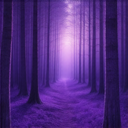

aesthetic_score =0.48, clip_score=28.19, score=381.44452800000005


  0%|          | 0/4 [00:00<?, ?it/s]

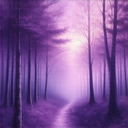

aesthetic_score =0.45, clip_score=28.12, score=355.83048


  0%|          | 0/4 [00:00<?, ?it/s]

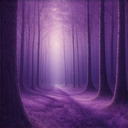

aesthetic_score =0.46, clip_score=26.85, score=331.62435000000005
final score: 381.44452800000005
layer_difference=30
svg length: 8324


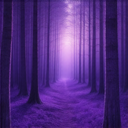

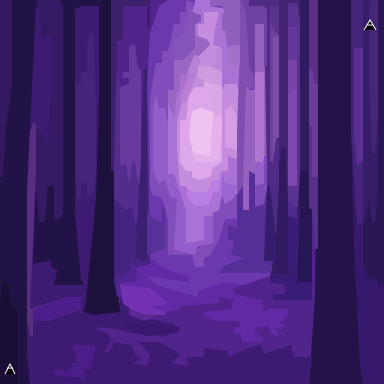

<svg width="384" height="384" viewBox="0 0 384 384"><g transform="scale(3.0)"><polygon points="0,0 128,0 128,128 0,128" fill="#51248C"/><polygon points="56,0 83,0 83,2 88,2 89,3 89,82 88,87 91,87 90,92 81,95 74,95 68,97 66,97 66,99 58,98 49,94 49,92 59,93 60,93 58,91 51,88 49,85 49,29 50,11 53,2" fill="#6C38AD"/><polygon points="0,0 37,0 38,57 39,94 40,104 31,105 28,104 29,97 32,66 33,2 25,3 26,71 28,95 26,96 17,96 19,90 16,89 17,87 11,88 11,57 12,42 15,46 16,49 17,30 17,28 17,12 15,12 14,14 13,4 10,64 10,128 0,128" fill="#221346"/><polygon points="106,0 128,0 128,128 103,128 105,98" fill="#241349"/><polygon points="12,2 14,5 15,12 17,12 18,26 19,26 19,61 18,61 17,49 14,58 12,57 11,88 17,87 17,89 19,90 18,95 28,95 27,93 25,71 25,3 27,2 33,2 33,66 30,97 28,104 40,104 40,99 43,102 44,105 58,108 60,110 55,112 43,111 40,110 33,109 32,110 36,111 37,114 35,117 36,118 38,114 44,115 45,118 47,120 44,121 49,122 50,118 46,114 53,114 60,118 57,121 63,122 62,119 68,119 68,116 76,117 76,119 83,116 

In [14]:
%%time
r = train_df.iloc[0]
description = r.description
svg, img = model.predict_impl(description)
display(img)
display(SVG(svg))
print(svg)

In [15]:
metric.score_instance(r.multiple_choice_qa, svg, random_seed=42)

decoded text =  A


{'competition_score': 0.8524535907312021,
 'vqa_score': 0.9966189464805519,
 'ocr_score': 1.0,
 'aesthetic_score': 0.54}

## Evaluate on train dataset (LB prediction!)

In [16]:
import matplotlib.pyplot as plt
%matplotlib inline

In [17]:
import pandas as pd
from tqdm.auto import tqdm
tqdm.pandas()

In [18]:
train_df.head()

,id,description,qa,question,choices,answer,multiple_choice_qa
0,02d892,a purple forest at dusk,"{'id': ['02d892', '02d892', '02d892', '02d892'...","[""What is the main setting of the image?"", ""Is...","[[""beach"", ""desert"", ""forest"", ""mountain""], [""...","[""forest"", ""yes"", ""dusk"", ""purple""]",{'question': ['What is the main setting of the...
1,0dcd2e,gray wool coat with a faux fur collar,"{'id': ['0dcd2e', '0dcd2e', '0dcd2e', '0dcd2e'...","[""What color is the coat?"", ""What part of the ...","[[""blue"", ""brown"", ""gray"", ""red""], [""collar"", ...","[""gray"", ""collar"", ""no"", ""wool""]","{'question': ['What color is the coat?', 'What..."
2,1e9ac1,a lighthouse overlooking the ocean,"{'id': ['1e9ac1', '1e9ac1', '1e9ac1', '1e9ac1'...","[""Is there an ocean visible in the image?"", ""W...","[[""no"", ""yes""], [""inside"", ""next to"", ""overloo...","[""yes"", ""overlooking"", ""no"", ""no""]",{'question': ['Is there an ocean visible in th...
3,2b25db,burgundy corduroy pants with patch pockets and...,"{'id': ['2b25db', '2b25db', '2b25db', '2b25db'...","[""Are the pants yellow?"", ""Do the pants have p...","[[""no"", ""yes""], [""no"", ""yes""], [""no"", ""yes""], ...","[""no"", ""yes"", ""yes"", ""pants""]","{'question': ['Are the pants yellow?', 'Do the..."
4,4e6a54,orange corduroy overalls,"{'id': ['4e6a54', '4e6a54', '4e6a54', '4e6a54'...","[""What material is the item?"", ""Is a hat depic...","[[""corduroy"", ""denim"", ""leather"", ""silk""], [""n...","[""corduroy"", ""no"", ""yes"", ""overalls""]","{'question': ['What material is the item?', 'I..."


  0%|          | 0/15 [00:00<?, ?it/s]

======= a purple forest at dusk =======


  0%|          | 0/4 [00:00<?, ?it/s]

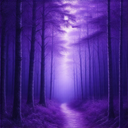

aesthetic_score =0.41, clip_score=21.74, score=193.77731599999998


  0%|          | 0/4 [00:00<?, ?it/s]

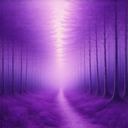

aesthetic_score =0.47, clip_score=20.23, score=192.348863


  0%|          | 0/4 [00:00<?, ?it/s]

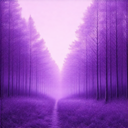

aesthetic_score =0.44, clip_score=18.33, score=147.83511599999997
final score: 193.77731599999998
layer_difference=40
svg length: 8847
======= gray wool coat with a faux fur collar =======


  0%|          | 0/4 [00:00<?, ?it/s]

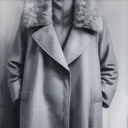

aesthetic_score =0.42, clip_score=17.77, score=132.62461799999997


  0%|          | 0/4 [00:00<?, ?it/s]

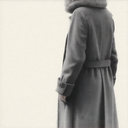

aesthetic_score =0.42, clip_score=18.44, score=142.81411200000002


  0%|          | 0/4 [00:00<?, ?it/s]

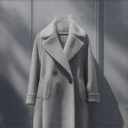

aesthetic_score =0.42, clip_score=11.27, score=53.345417999999995
final score: 142.81411200000002
layer_difference=30
svg length: 8491
======= a lighthouse overlooking the ocean =======


  0%|          | 0/4 [00:00<?, ?it/s]

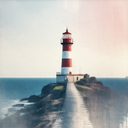

aesthetic_score =0.52, clip_score=24.59, score=314.427412


  0%|          | 0/4 [00:00<?, ?it/s]

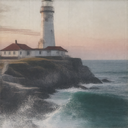

aesthetic_score =0.47, clip_score=19.38, score=176.52466799999996


  0%|          | 0/4 [00:00<?, ?it/s]

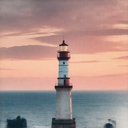

aesthetic_score =0.4, clip_score=22.26, score=198.20304000000004
final score: 314.427412
layer_difference=50
svg length: 7968
======= burgundy corduroy pants with patch pockets and silver buttons =======


  0%|          | 0/4 [00:00<?, ?it/s]

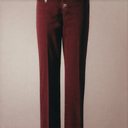

aesthetic_score =0.42, clip_score=26.87, score=303.238698


  0%|          | 0/4 [00:00<?, ?it/s]

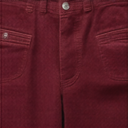

aesthetic_score =0.32, clip_score=27.53, score=242.52828800000006


  0%|          | 0/4 [00:00<?, ?it/s]

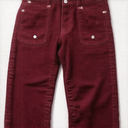

aesthetic_score =0.4, clip_score=30.73, score=377.73316000000005
final score: 377.73316000000005
layer_difference=30
svg length: 9769
======= orange corduroy overalls =======


  0%|          | 0/4 [00:00<?, ?it/s]

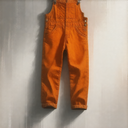

aesthetic_score =0.4, clip_score=22.68, score=205.75296000000003


  0%|          | 0/4 [00:00<?, ?it/s]

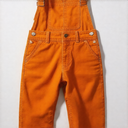

aesthetic_score =0.37, clip_score=29.15, score=314.39732499999997


  0%|          | 0/4 [00:00<?, ?it/s]

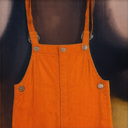

aesthetic_score =0.4, clip_score=21.93, score=192.36996
final score: 314.39732499999997
layer_difference=30
svg length: 9398
======= a purple silk scarf with tassel trim =======


  0%|          | 0/4 [00:00<?, ?it/s]

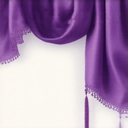

aesthetic_score =0.43, clip_score=25.51, score=279.82684300000005


  0%|          | 0/4 [00:00<?, ?it/s]

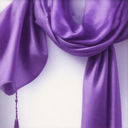

aesthetic_score =0.44, clip_score=27.58, score=334.688816


  0%|          | 0/4 [00:00<?, ?it/s]

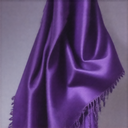

aesthetic_score =0.46, clip_score=28.1, score=363.22060000000005
final score: 363.22060000000005
layer_difference=40
svg length: 8380
======= a green lagoon under a cloudy sky =======


  0%|          | 0/4 [00:00<?, ?it/s]

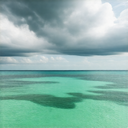

aesthetic_score =0.47, clip_score=27.51, score=355.696047


  0%|          | 0/4 [00:00<?, ?it/s]

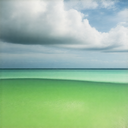

aesthetic_score =0.5, clip_score=24.73, score=305.78645


  0%|          | 0/4 [00:00<?, ?it/s]

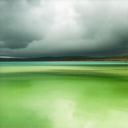

aesthetic_score =0.49, clip_score=24.58, score=296.0464359999999
final score: 355.696047
layer_difference=40
svg length: 7920
======= crimson rectangles forming a chaotic grid =======


  0%|          | 0/4 [00:00<?, ?it/s]

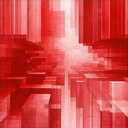

aesthetic_score =0.39, clip_score=24.32, score=230.670336


  0%|          | 0/4 [00:00<?, ?it/s]

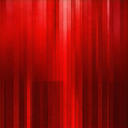

aesthetic_score =0.42, clip_score=21.02, score=185.572968


  0%|          | 0/4 [00:00<?, ?it/s]

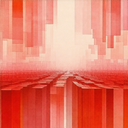

aesthetic_score =0.43, clip_score=21.33, score=195.63662699999998
final score: 230.670336
layer_difference=40
svg length: 9549
======= purple pyramids spiraling around a bronze cone =======


  0%|          | 0/4 [00:00<?, ?it/s]

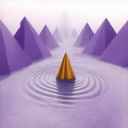

aesthetic_score =0.46, clip_score=22.07, score=224.059054


  0%|          | 0/4 [00:00<?, ?it/s]

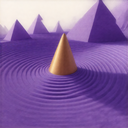

aesthetic_score =0.44, clip_score=28.05, score=346.1931


  0%|          | 0/4 [00:00<?, ?it/s]

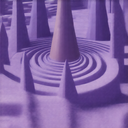

aesthetic_score =0.37, clip_score=22.08, score=180.38476799999998
final score: 346.1931
layer_difference=30
svg length: 9609
======= magenta trapezoids layered on a transluscent silver sheet =======


  0%|          | 0/4 [00:00<?, ?it/s]

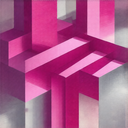

aesthetic_score =0.43, clip_score=26.48, score=301.511872


  0%|          | 0/4 [00:00<?, ?it/s]

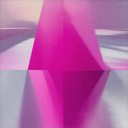

aesthetic_score =0.41, clip_score=28.19, score=325.817201


  0%|          | 0/4 [00:00<?, ?it/s]

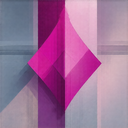

aesthetic_score =0.42, clip_score=27.68, score=321.79660799999994
final score: 325.817201
layer_difference=30
svg length: 6688
======= a snowy plain =======


  0%|          | 0/4 [00:00<?, ?it/s]

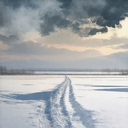

aesthetic_score =0.49, clip_score=25.02, score=306.740196


  0%|          | 0/4 [00:00<?, ?it/s]

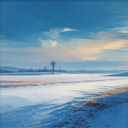

aesthetic_score =0.52, clip_score=21.17, score=233.04782800000007


  0%|          | 0/4 [00:00<?, ?it/s]

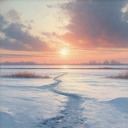

aesthetic_score =0.49, clip_score=24.36, score=290.77070399999997
final score: 306.740196
layer_difference=50
svg length: 7819
======= black and white checkered pants =======


  0%|          | 0/4 [00:00<?, ?it/s]

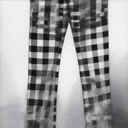

aesthetic_score =0.35, clip_score=25.48, score=227.23064


  0%|          | 0/4 [00:00<?, ?it/s]

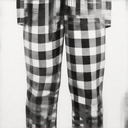

aesthetic_score =0.4, clip_score=22.32, score=199.27296


  0%|          | 0/4 [00:00<?, ?it/s]

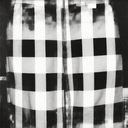

aesthetic_score =0.41, clip_score=18.81, score=145.06460099999995
final score: 227.23064
layer_difference=100
svg length: 9862
======= a starlit night over snow-covered peaks =======


  0%|          | 0/4 [00:00<?, ?it/s]

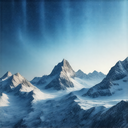

aesthetic_score =0.49, clip_score=19.27, score=181.95312099999998


  0%|          | 0/4 [00:00<?, ?it/s]

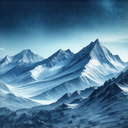

aesthetic_score =0.51, clip_score=17.57, score=157.439499


  0%|          | 0/4 [00:00<?, ?it/s]

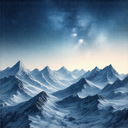

aesthetic_score =0.48, clip_score=19.64, score=185.150208
final score: 185.150208
layer_difference=70
svg length: 8795
======= khaki triangles and azure crescents =======


  0%|          | 0/4 [00:00<?, ?it/s]

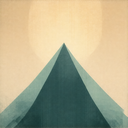

aesthetic_score =0.48, clip_score=19.77, score=187.60939199999999


  0%|          | 0/4 [00:00<?, ?it/s]

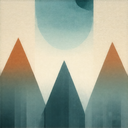

aesthetic_score =0.47, clip_score=20.8, score=203.3408


  0%|          | 0/4 [00:00<?, ?it/s]

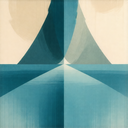

aesthetic_score =0.45, clip_score=24.15, score=262.45012499999996
final score: 262.45012499999996
layer_difference=20
svg length: 8318
======= a maroon dodecahedron interwoven with teal threads =======


  0%|          | 0/4 [00:00<?, ?it/s]

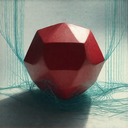

aesthetic_score =0.45, clip_score=25.97, score=303.498405


  0%|          | 0/4 [00:00<?, ?it/s]

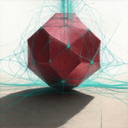

aesthetic_score =0.39, clip_score=28.78, score=323.03247600000003


  0%|          | 0/4 [00:00<?, ?it/s]

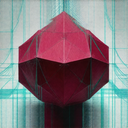

aesthetic_score =0.44, clip_score=26.12, score=300.19193600000006
final score: 323.03247600000003
layer_difference=50
svg length: 6977
CPU times: user 1min 8s, sys: 7.97 s, total: 1min 16s
Wall time: 49.1 s


In [19]:
%%time
train_df['raw_res'] = train_df.description.progress_apply(model.predict_impl)

In [20]:
train_df['svg'] = train_df.raw_res.apply(lambda x: x[0])
train_df['bitmap'] = train_df.raw_res.apply(lambda x: x[1])

In [21]:
train_df['bitmap_score'] = train_df.progress_apply(
    lambda r: bitmap_score_instance(r.multiple_choice_qa, r.bitmap, random_seed=42),
    axis=1,
)

  0%|          | 0/15 [00:00<?, ?it/s]

decoded text =  ©2012
decoded text =  © Instagram
decoded text =  1
decoded text =  V
decoded text =  V
decoded text =  www.ay.by
decoded text =  © PA
decoded text =  © Getty Images
decoded text =  © Getty Images
decoded text =  © PA
decoded text =  pikabu.ru
decoded text =  V
decoded text =  WALLPAPERSWIDE.COM
decoded text =  © 2016
decoded text =  © Getty Images


In [22]:
train_df['svg_score'] = train_df.progress_apply(
    lambda r: metric.score_instance(r.multiple_choice_qa, r.svg, random_seed=42),
    axis=1,
)

  0%|          | 0/15 [00:00<?, ?it/s]

decoded text =  A
decoded text =  A
decoded text =  A
decoded text =  A
decoded text =  A
decoded text =  A
decoded text =  A
decoded text =  A
decoded text =  A
decoded text =  A
decoded text =  A
decoded text =  A
decoded text =  A
decoded text =  A
decoded text =  A


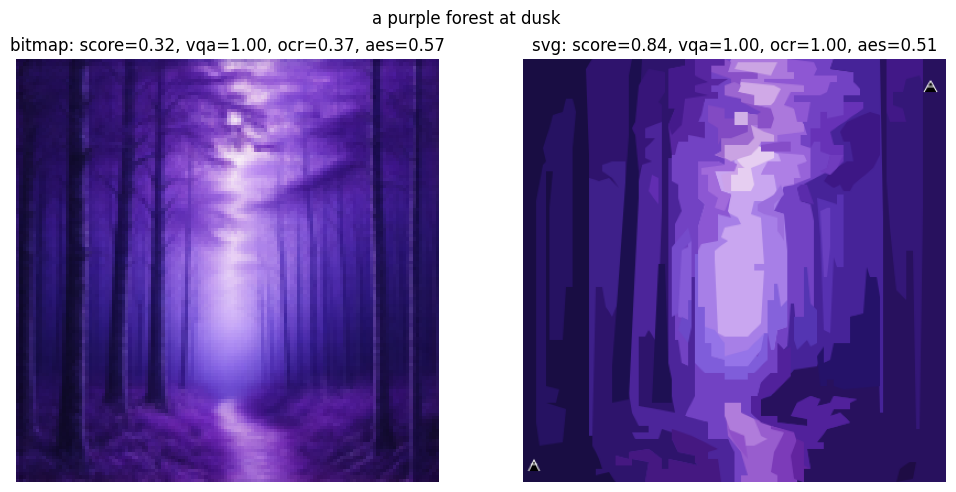

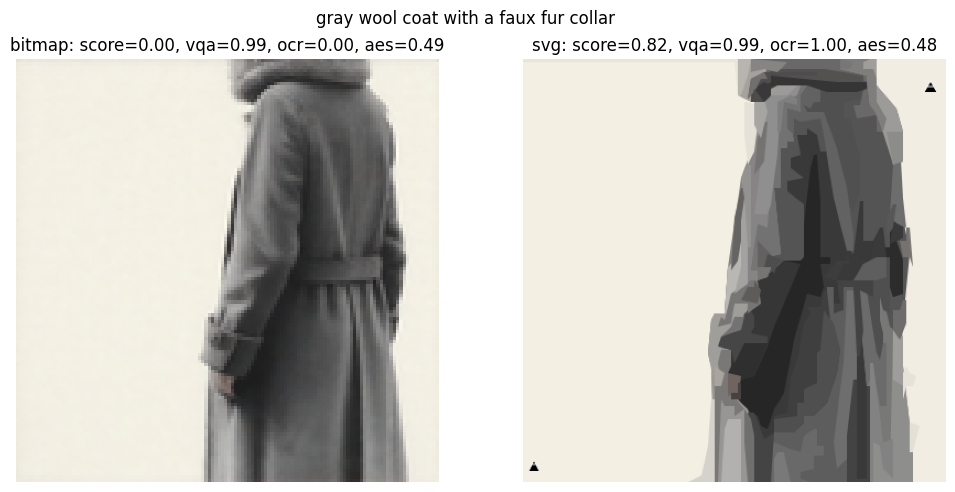

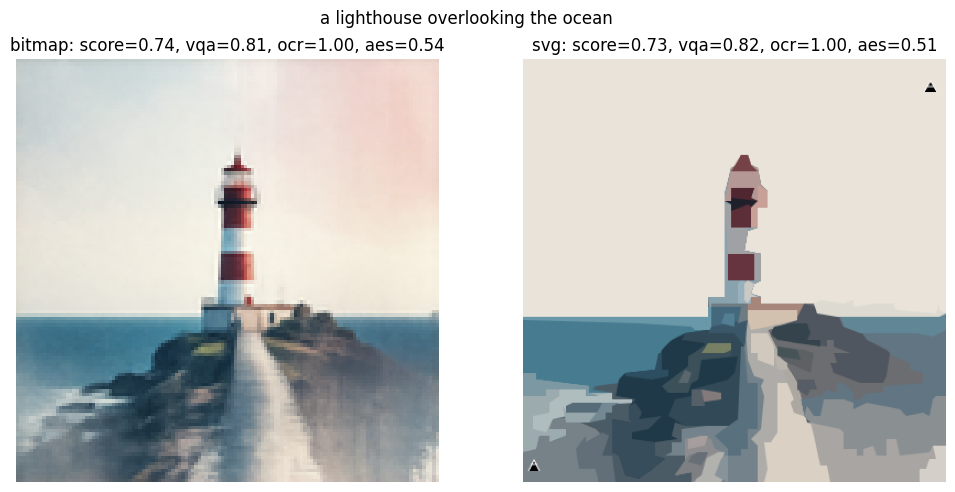

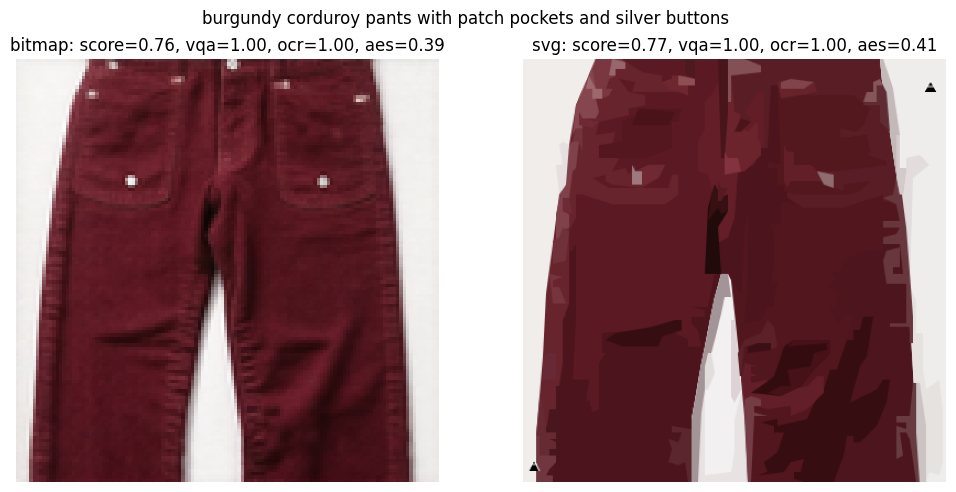

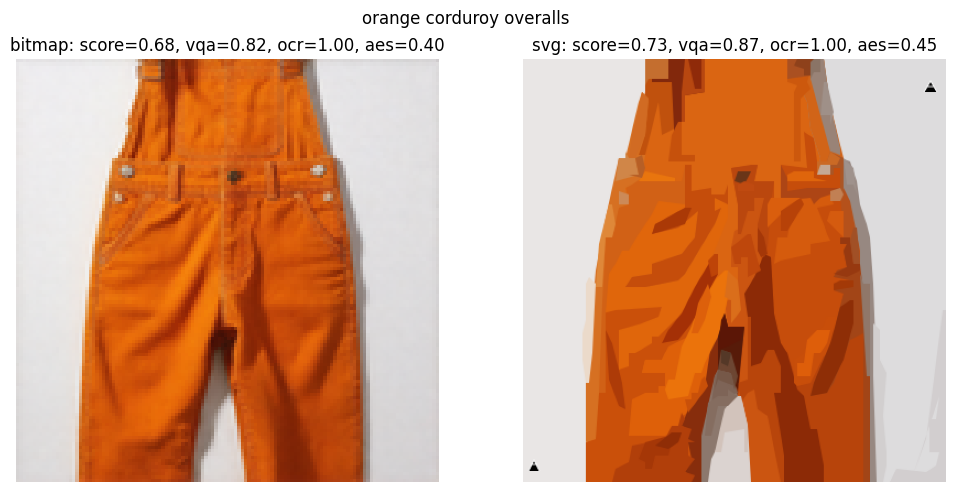

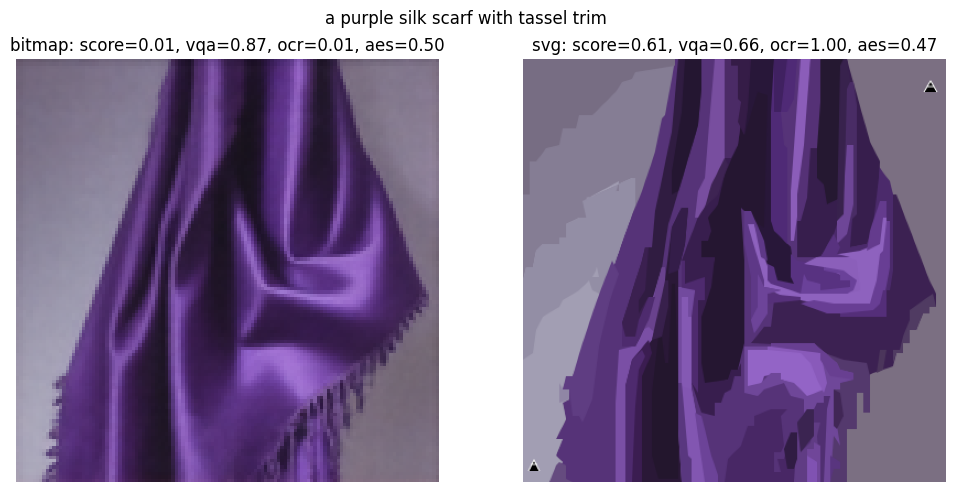

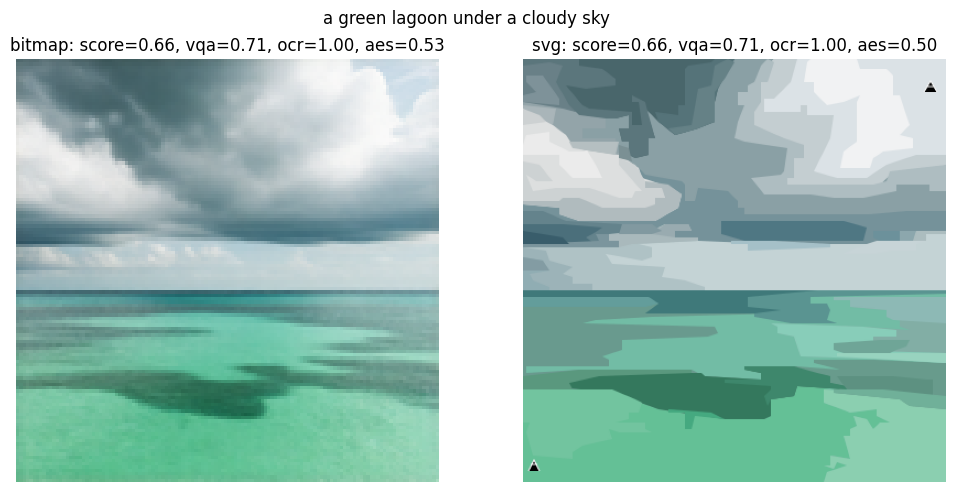

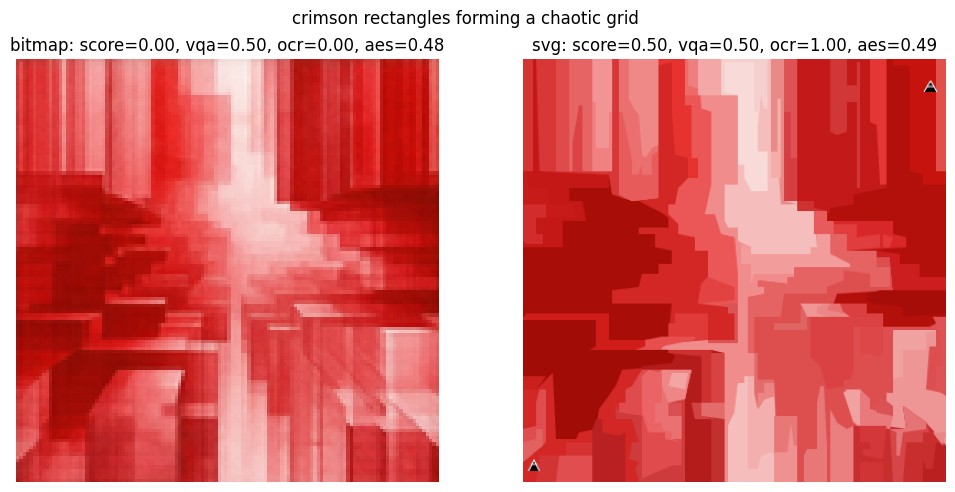

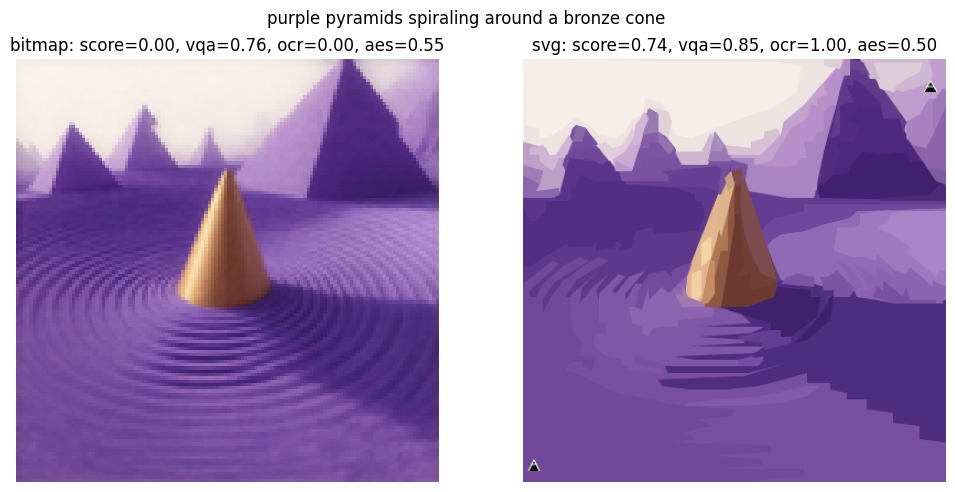

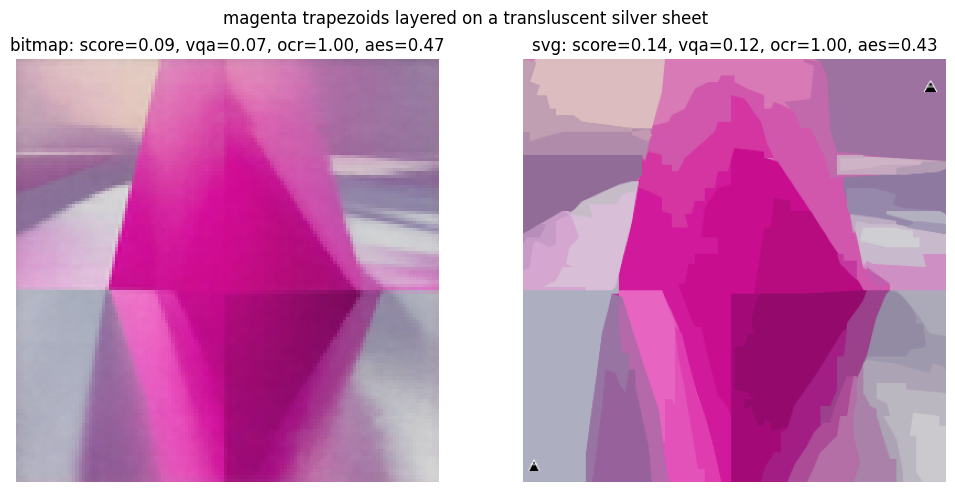

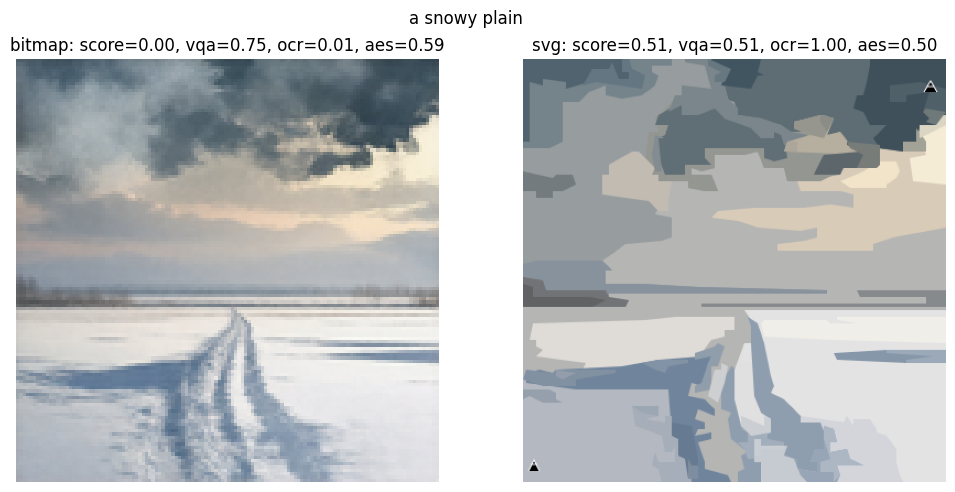

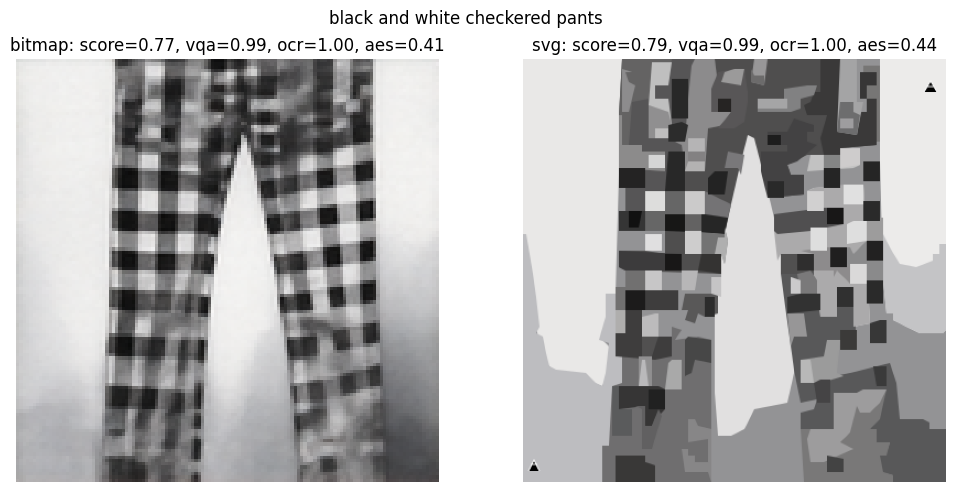

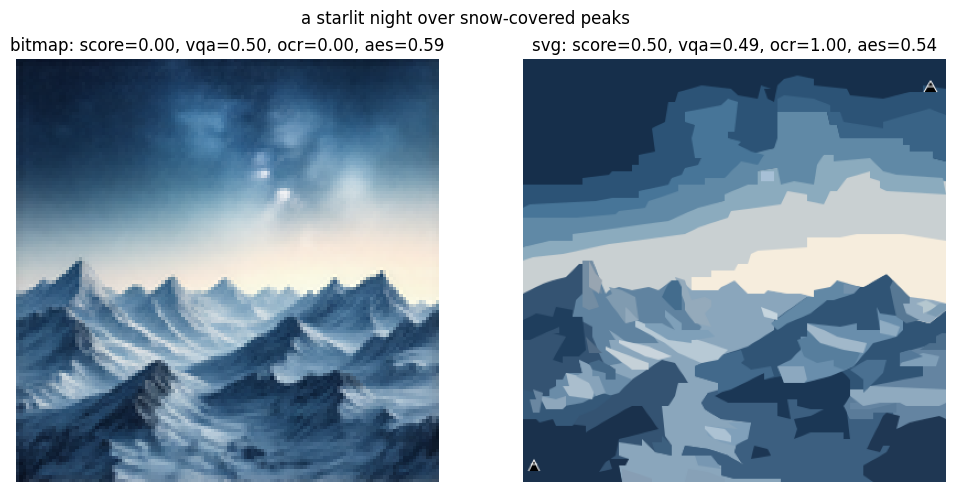

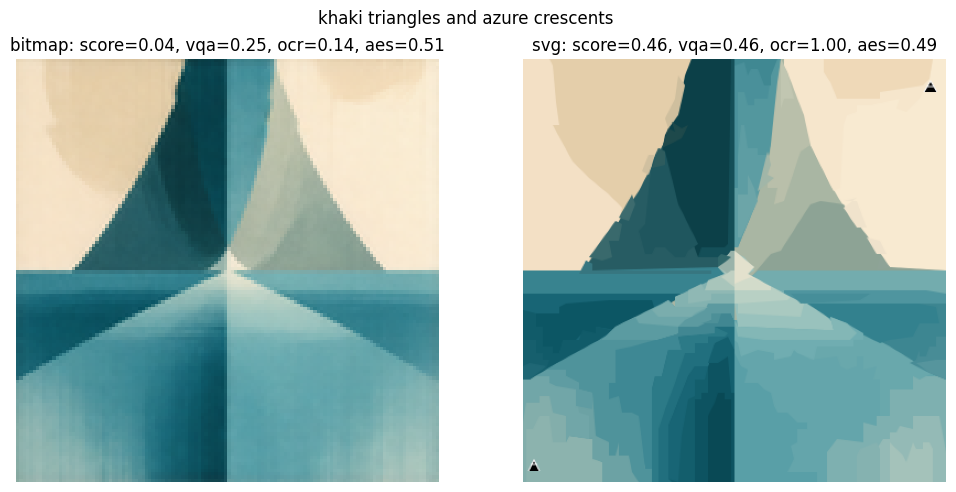

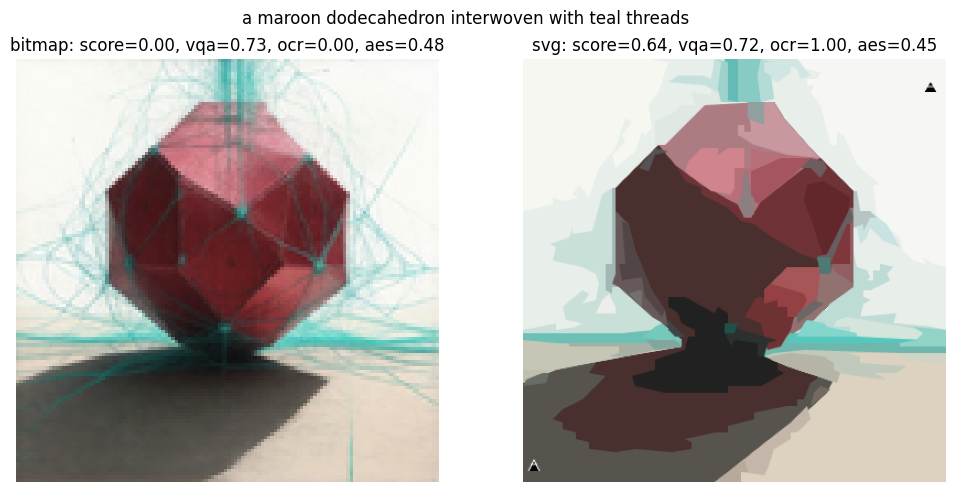

In [23]:
for r in train_df.itertuples():
    
    b_vqa = r.bitmap_score['vqa_score']
    b_aesthetic = r.bitmap_score['aesthetic_score']
    b_ocr = r.bitmap_score['ocr_score']
    b_score = r.bitmap_score['competition_score']

    
    s_vqa = r.svg_score['vqa_score']
    s_aesthetic = r.svg_score['aesthetic_score']
    s_ocr = r.svg_score['ocr_score']
    s_score = r.svg_score['competition_score']
    
    plt.figure(figsize=(12, 6))
    plt.suptitle(r.description, y=0.93)
    
    plt.subplot(1, 2, 1)
    plt.imshow(np.array(r.bitmap))
    plt.axis('off')
    plt.title(f'bitmap: score={b_score:.2f}, vqa={b_vqa:.2f}, ocr={b_ocr:.2f}, aes={b_aesthetic:.2f}')

    plt.subplot(1, 2, 2)
    plt.imshow(metric.svg_to_png(r.svg))
    plt.axis('off')
    plt.title(f'svg: score={s_score:.2f}, vqa={s_vqa:.2f}, ocr={s_ocr:.2f}, aes={s_aesthetic:.2f}')

In [24]:
mean_bitmap_score = pd.DataFrame(train_df['bitmap_score'].tolist()).mean(axis=0)
mean_bitmap_score

competition_score    0.271195
vqa_score            0.717604
ocr_score            0.434516
aesthetic_score      0.500000
dtype: float64

In [25]:
mean_svg_score = pd.DataFrame(train_df['svg_score'].tolist()).mean(axis=0)
mean_svg_score

competition_score    0.630037
vqa_score            0.712429
ocr_score            1.000000
aesthetic_score      0.478000
dtype: float64

In [26]:
print(f'Original bitmap score: {mean_bitmap_score.competition_score}')
print(f'Final svg score: {mean_svg_score.competition_score}')

Original bitmap score: 0.2711952048931081
Final svg score: 0.6300369437436485
